In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import json
import re
pd.set_option('mode.chained_assignment', None)
import networkx as nx

In [3]:
def add_clock(df):
    df['hour'] = df['time']/3600
    df['minute'] = (df['time'] - df['hour']*3600) / 60
    df['seconds'] = df['time'] - (df['hour']*3600) - (df['minute'] * 60)
    df['clock'] = pd.to_datetime("2025-06-26") + pd.to_timedelta(df['time'], unit='s')
    df['sim_clock'] = df.clock.apply(lambda x: pd.Timestamp(x).strftime('%H:%M:%S'))
    return(df)

In [4]:
def tidy_oids_to_names(n):
    n = n.replace("/root/Main/Map/","").replace("Level1/","")
    if 'Entrance' in n.split('/')[-1]:
        n = '-'.join(n.replace('1','').replace('EntranceContainer','Main').split('/'))
    else:
        n = n.split('/')[-1]
    return(n)

In [5]:
out_dir = '/project/biocomplexity/dtra/Toxin_Building_2025/chem-poison-godot-data/2025-08-25/'
out_fname = 'output_negvalues-fix_Aug25.json'
out_df = pd.read_json(out_dir+out_fname,lines=True)

In [6]:
pe_df = out_df[out_df.event=='poison_exchange']
pe_df = add_clock(pe_df)
pe_df['obj_name'] = pe_df.oid.apply(lambda x: tidy_oids_to_names(x))

In [7]:
### some pids have two different oids at same clock. e.g., 1926074 has Restroom4 and Restroom5
pe_df = pe_df.drop_duplicates(['pid','clock'],keep='last')
pvt_df = pe_df.pivot(index='clock',columns='pid',values='pid_poison_end')
pvt_df.iloc[0] = 0
pvt_df = pvt_df.ffill()

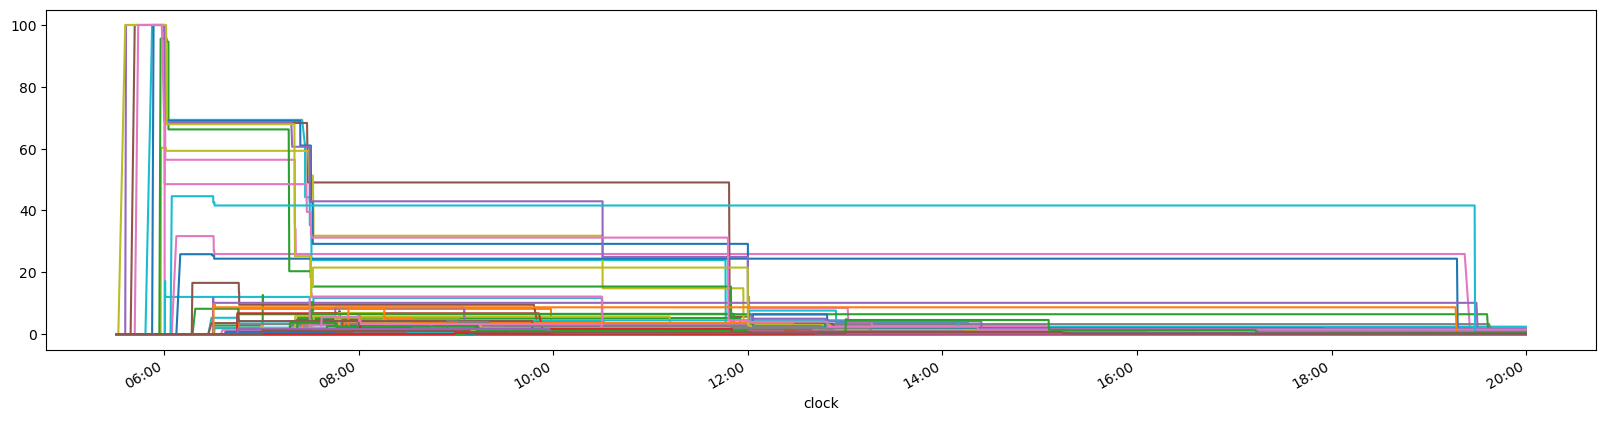

In [8]:
true_pids = (pvt_df.sum().round()!=0).index.values
pvt_df[true_pids].plot(legend=False,figsize=(20,5))
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

In [9]:
true_pe = pe_df[(pe_df.oid_poison_start!=pe_df.oid_poison_end)&(pe_df.pid_poison_start!=pe_df.pid_poison_end)]
true_pe['transfer_to_pid'] = true_pe.apply(lambda x: x['pid_poison_end'] - x['pid_poison_start'],axis=1)
true_pe['transfer_to_obj'] = true_pe.apply(lambda x: x['oid_poison_end'] - x['oid_poison_start'],axis=1)
true_pe = true_pe[(true_pe.transfer_to_pid.round()!=0)&(true_pe.transfer_to_obj.round()!=0)]

true_pe['source'] = true_pe.apply(lambda x: x['pid'] if x['transfer_to_pid']<0 else x['obj_name'],axis=1)
true_pe['target'] = true_pe.apply(lambda x: x['pid'] if x['transfer_to_pid']>=0 else x['obj_name'],axis=1)
true_pe['volume'] = true_pe['transfer_to_pid'].apply(lambda x: np.abs(x))

true_pe = true_pe[['source','target','sim_clock','volume']]

In [14]:
tx_thresh = 0
G = nx.from_pandas_edgelist(true_pe[true_pe.volume>=tx_thresh],
                         'source','target', edge_attr=True, create_using=nx.MultiDiGraph)
for n in G.nodes():
    if isinstance(n,int):
        G.nodes[n]['color'] = '#3182bd'
    else:
        G.nodes[n]['color'] = '#e6550d'
colors = [G.nodes[node]['color'] for node in list(G.nodes())]

Text(0.5, 1.0, 'Poison exchange events')

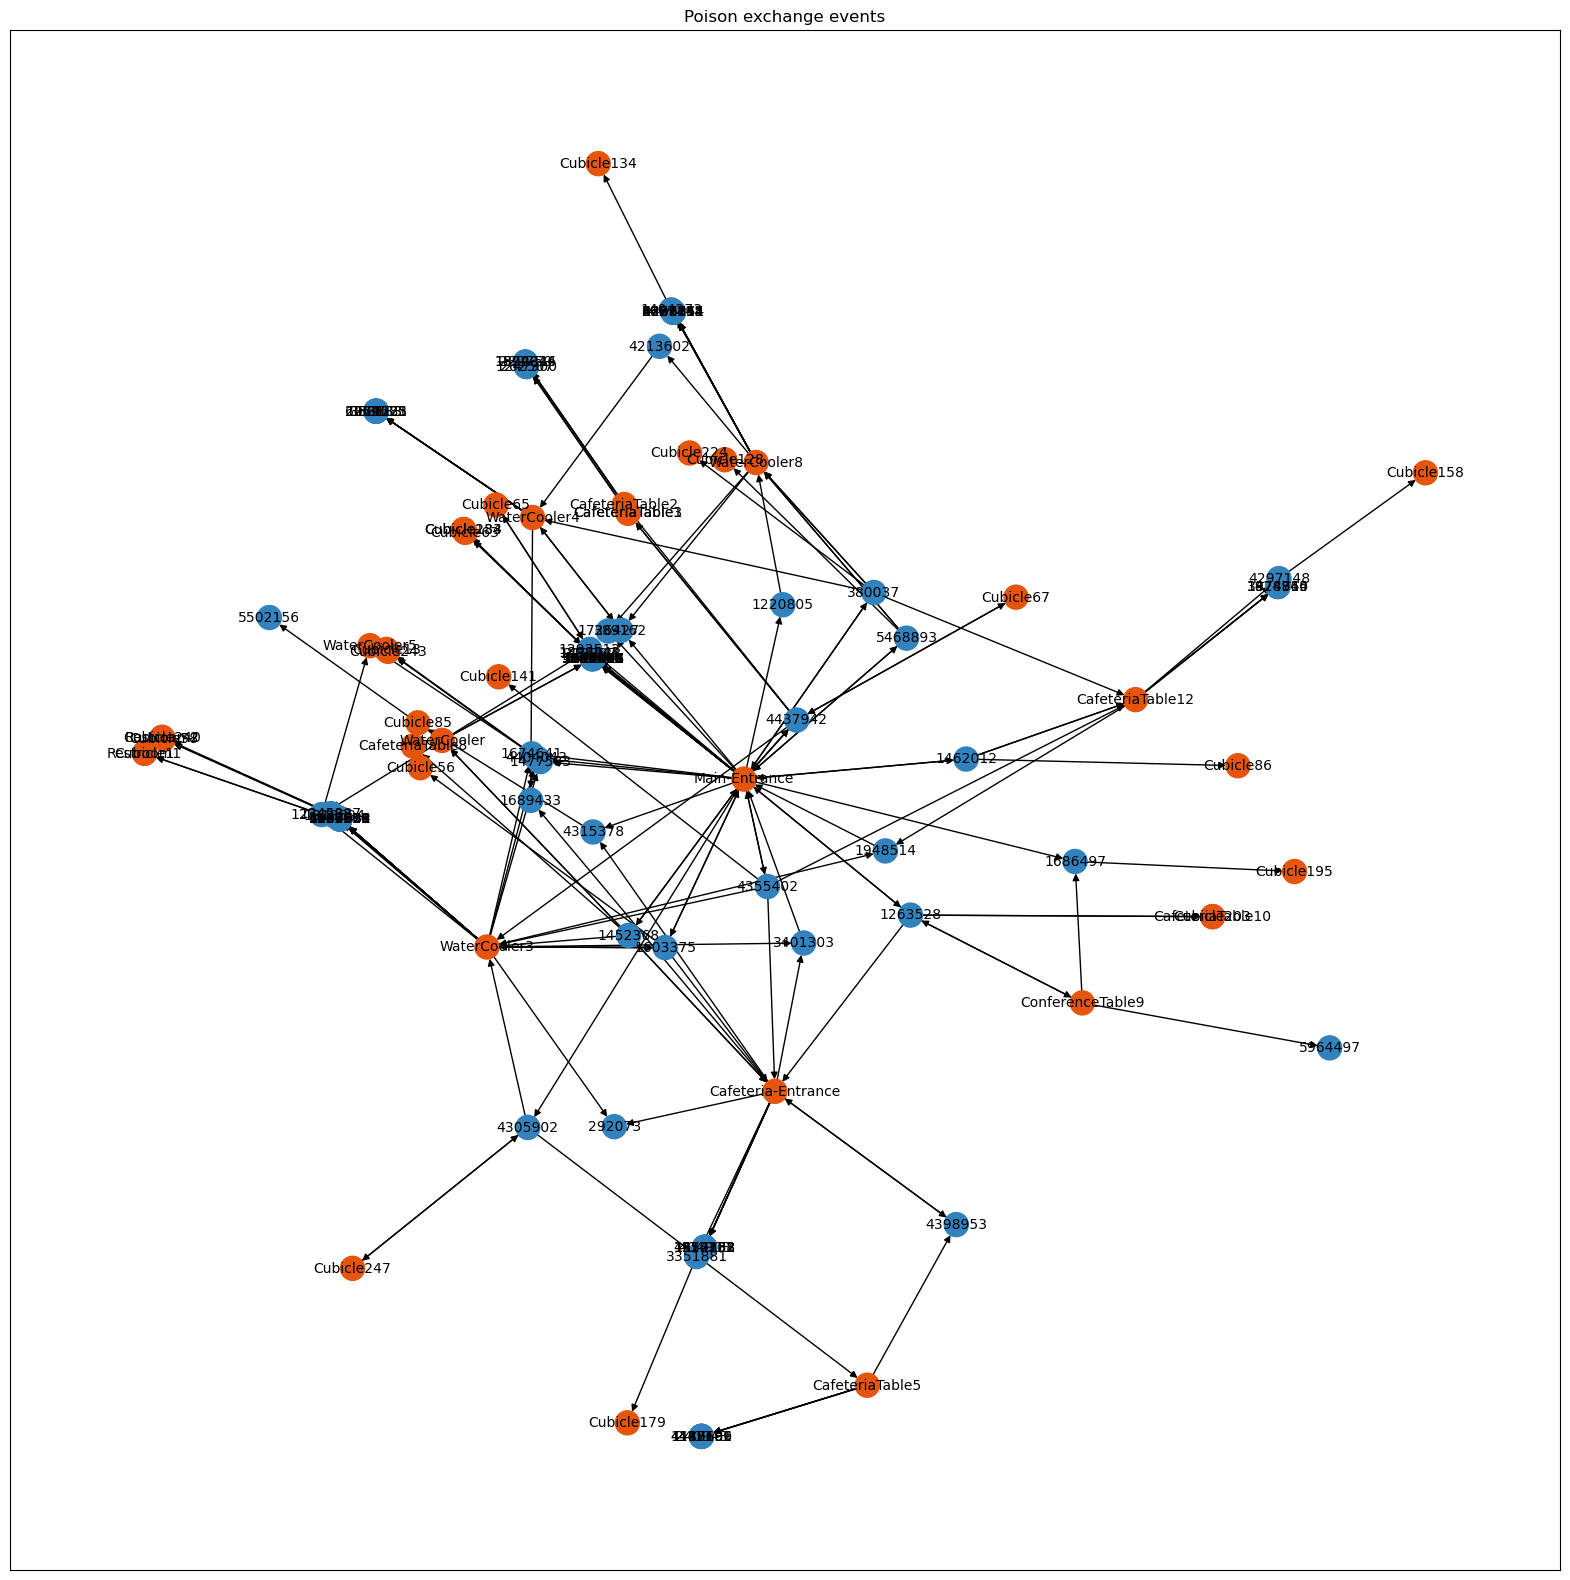

In [15]:
plt.figure(figsize=(20,20))
ax = plt.gca()
pos = nx.kamada_kawai_layout(G)
nx.draw_networkx(G, pos, node_color=colors,ax=ax,font_size=10)

edge_times = nx.get_edge_attributes(G,'sim_clock')
edge_vols = nx.get_edge_attributes(G,'volume')
edge_labels = {}
for k in edge_times.keys():
    edge_labels[k] = edge_times[k]+','+str(round(edge_vols[k]))
#nx.draw_networkx_edge_labels(G,pos,edge_labels = edge_labels,font_size=10)
plt.title('Poison exchange events')

#### Network metrics

In [16]:
print('Top 10 nodes by weighted betweenness (source excluded)')
pd.Series(nx.betweenness_centrality(G,weight='volume')).sort_values(ascending=False).head(11).iloc[1:]

Top 10 nodes by weighted betweenness (source excluded)


3401303               0.056825
WaterCooler3          0.054540
4437942               0.040317
Cafeteria-Entrance    0.035810
4398953               0.019238
CafeteriaTable5       0.016508
4305902               0.014476
WaterCooler8          0.013143
1263528               0.012317
1220805               0.011429
dtype: float64

In [12]:
print("Top 10 depositors of poison (source excluded)")
idx, values = zip(*list(G.out_degree(weight='volume')))
pd.Series(values,idx).sort_values(ascending=False).head(11).iloc[1:]

Top 10 depositors of poison (source excluded)


4437942         76.940223
380037          75.860979
1603375         70.214816
1263528         67.140117
WaterCooler3    66.808037
4305902         60.810000
5468893         59.574771
1452368         59.488980
4355402         56.013070
WaterCooler8    51.011581
dtype: float64

In [13]:
print("Top 10 depositors of poison - count (source excluded)")
idx, values = zip(*list(G.out_degree()))
pd.Series(values,idx).sort_values(ascending=False).head(11).iloc[1:]

Top 10 depositors of poison - count (source excluded)


WaterCooler3          22
Cafeteria-Entrance    11
WaterCooler8          10
WaterCooler4           7
1452368                7
380037                 6
4437942                6
CafeteriaTable5        5
1263528                5
WaterCooler            5
dtype: int64

In [14]:
max_hops = max(nx.shortest_path_length(G,source='Main-Entrance').values())
print("Maximum hops from source: {}".format(max_hops))

Maximum hops from source: 4
